<!-- scprint2-nb-header:begin -->
# Fine-tuning scPRINT-2 (cell type / batch correction / 4-species eye tissue)

Full fine-tuning loop using the `tasks/finetune.py` helper class: dataloaders, additional modules, what to freeze/train, MMD loss for cross-species alignment, saving the fine-tuned checkpoint, and evaluating the result.

**Dataset:** van Zyl et al. 2020 (PNAS), aqueous humor outflow pathways.

**Species:** Human, Macaque fascicularis, Mouse, Pig.

## Contents

- [load the data](#load-the-data)
- [Preparing the finetuner](#preparing-the-finetuner)
    - [dataloaders](#dataloaders)
    - [additional modules](#additional-modules)
    - [what to finetune](#what-to-finetune)
    - [forward pass](#forward-pass)
    - [trainer and optimizer](#trainer-and-optimizer)
    - [training loop](#training-loop)
- [saving the finetuned model](#saving-the-finetuned-model)
  - [using it and checking its performance](#using-it-and-checking-its-performance)

> _Run `notebooks/prepare_scprint2.ipynb` once before any other example notebook._

<!-- scprint2-nb-header:end -->

In [1]:
import scanpy as sc
from scprint2 import scPRINT2
from scdataloader import Preprocessor
from scdataloader.utils import load_genes
import numpy as np
import anndata as ad
from huggingface_hub import hf_hub_download
import lamindb as ln

from scprint2.tasks import Embedder
from scprint2.tasks.cell_emb import display_confusion_matrix
import pandas as pd

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
from anndata import AnnData
from scdataloader.utils import translate
import bionty as bt
from scprint2.tasks.cell_emb import compute_classification

from lightning.pytorch import Trainer
from lightning.pytorch.loggers import TensorBoardLogger
from scdataloader import SimpleAnnDataset, Collator, DataModule
from torch.utils.data import DataLoader

import lamindb as ln
import os.path
import urllib.request

%load_ext autoreload
%autoreload 2

import torch
import scipy.sparse

torch.set_float32_matmul_precision("medium")

→ connected lamindb: jkobject/scprint2


In [2]:
LOC2 = "/pasteur/appa/scratch/jkalfon/models/"  
ckpt_path = os.path.join(LOC2, "small-v2.ckpt")
# w937u4o1.ckpt'
# da6ao55o.ckpt # 649
# 1lzuxvg0.ckpt # 677
if not os.path.exists(ckpt_path):
    url = (
        "https://huggingface.co/jkobject/scPRINT/resolve/main/other_ckpts/small-v2.ckpt"
    )
    urllib.request.urlretrieve(url, ckpt_path)

model = scPRINT2.load_from_checkpoint(
    ckpt_path, precpt_gene_emb=None, gene_pos_file=None
)
if not torch.cuda.is_available():
    model = model.to(torch.float32)

model = model.to("cuda" if torch.cuda.is_available() else "cpu")
missing = set(model.genes) - set(load_genes(model.organisms).index)
if len(missing) > 0:
    print(
        "Warning: some genes missmatch exist between model and ontology: solving...",
    )
    model._rm_genes(missing)

FYI: scPRINT2 is not attached to a `Trainer`.


/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scdataloader/utils.py:429: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  organismdf = pd.concat(organismdf)


# load the data

check the cross-species-embedding notebook to see how we create this anndata


In [3]:
LOC = "/pasteur/appa/scratch/jkalfon/data/spcrint_data/"  # "./"

da = sc.read(LOC + "task_4_multi_species_embed_ines.h5ad")
da

AnnData object with n_obs × n_vars = 16228 × 57066
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'cell_type', 'batch', 'n_genes', 'celltype', 'organism_ontology_term_id', 'nnz', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'batches', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'CL:0000001', 'CL:0000003', 'CL:0000019', 'CL:0000023', 'CL:0000024', 'CL:0000032', 'CL:0000047', 'CL:0000049', 'CL:0000050', 'CL:0000051', 'CL:0000062', 'CL:0000091', 'CL:0000092', 'CL:0000097', 'CL:0000114', 'CL:0000119', 'CL:0000121', 'CL:0000122', 'CL:0000128', 'CL:0000131', 'CL:0000132', 'CL:0000133', 'CL:0000138', 'CL:0000155', 'CL:0000158', 'CL:0000162', 'CL:0000169', 'CL:0000171', 'CL:0000173', 'CL:

In [4]:
# only because we are using a specific anndata that kept all predicted logits per class here
# but should not be required
da.obs = da.obs.loc[:, da.obs.columns[:29]]
da

AnnData object with n_obs × n_vars = 16228 × 57066
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'cell_type', 'batch', 'n_genes', 'celltype', 'organism_ontology_term_id', 'nnz', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'batches', 'assay_ontology_term_id', 'cell_type_ontology_term_id'
    var: 'uid', 'symbol', 'biotype', 'is_locked', 'branch_id', 'organism_id', 'mt', 'ribo', 'hb', 'organism', 'ensembl_gene_id', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p', 'neighbors', 'pca', 'unseen_genes'
    obsm: 'X_pca', 'scprint_emb', 'scprint_emb_age_group', 'scprint_emb_assay_ontology_term_id', 'scprint_emb_

In [5]:
n_genes_per_cell = (da.X > 0).sum(1)
print(f"Genes detected per cell - mean: {n_genes_per_cell.mean():.0f}, "
      f"max: {n_genes_per_cell.max()}, min: {n_genes_per_cell.min()}")

Genes detected per cell - mean: 304, max: 751, min: 198


Filter cells with unknown cell types: 

In [6]:
mencoders = {}
for k, v in model.label_decoders.items():
    mencoders[k] = {va: ke for ke, va in v.items()}
mencoders.pop("organism_ontology_term_id")

known_types = set(mencoders["cell_type_ontology_term_id"].keys())
da = da[da.obs["cell_type_ontology_term_id"].isin(known_types)].copy()
print(f"Kept: {da.shape[0]} cells, {da.obs['batch'].nunique()} species")

map_to_val = {n: i for i, n in enumerate(sorted(da.obs["batch"].unique()))}
da.obs["batch"] = da.obs["batch"].map(map_to_val)

Kept: 13136 cells, 4 species


# Preparing the finetuner

a specific class now exists exactly for that in `tasks/finetune.py``


### dataloaders


In [7]:
n_train = int(0.8 * len(da))
train_idx = np.random.choice(len(da), n_train, replace=False)
val_idx = np.setdiff1d(np.arange(len(da)), train_idx)

train_data = da[train_idx].copy()
val_data = da[val_idx].copy()

print(f"Training data: {train_data.shape}")
print(f"Validation data: {val_data.shape}")

Training data: (10508, 57066)
Validation data: (2628, 57066)


In [8]:
# Create datasets
train_dataset = SimpleAnnDataset(
    train_data,
    obs_to_output=["cell_type_ontology_term_id", "batch", "organism_ontology_term_id"],
    get_knn_cells=model.expr_emb_style == "metacell",
    encoder=mencoders,
)

val_dataset = SimpleAnnDataset(
    val_data,
    obs_to_output=["cell_type_ontology_term_id", "batch", "organism_ontology_term_id"],
    get_knn_cells=model.expr_emb_style == "metacell",
    encoder=mencoders,
)

# Create collator
collator = Collator(
    organisms=model.organisms,
    valid_genes=model.genes,
    class_names=["cell_type_ontology_term_id", "batch"],
    how="random expr",  # or "all expr" for full expression
    max_len=2200,
    add_zero_genes=0,
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    collate_fn=collator,
    batch_size=32,  # Adjust based on GPU memory
    num_workers=4,
    shuffle=True,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    collate_fn=collator,
    batch_size=32,
    num_workers=4,
    shuffle=True,
    pin_memory=True,
)

/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scdataloader/utils.py:429: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  organismdf = pd.concat(organismdf)


### additional modules


In [9]:
d_model_org = 8
d_model_cell = 256
batch_cls = torch.nn.Sequential(
    torch.nn.Linear(d_model_org, d_model_org * 8),
    torch.nn.ReLU(),
    torch.nn.Linear(d_model_org * 8, len(set(da.obs["batch"].unique()))),
)
batch_cls = batch_cls.to(model.device)

batch_emb = torch.nn.Embedding(len(set(da.obs["batch"].unique())), d_model_cell).to(
    model.device
)

### what to finetune


In [10]:
for val in model.parameters():
    val.requires_grad = False
    # setting all to TRUE

for val in model.cell_transformer.parameters():
    val.requires_grad = True
for val in model.transformer.blocks[7].parameters():
    val.requires_grad = True
for i in model.transformer.blocks:
    i.cross_attn.requires_grad = True
for val in model.compressor.parameters():
    val.requires_grad = True
for val in model.cls_decoders["cell_type_ontology_term_id"].parameters():
    val.requires_grad = True

for val in batch_emb.parameters():
    val.requires_grad = True

### forward pass


In [11]:
def mmd_loss(X, Y):
    """
    Compute Maximum Mean Discrepancy (MMD) loss between two 2D embedding matrices.

    Args:
        X: Tensor of shape (n1, emb_dim) - first set of embeddings
        Y: Tensor of shape (n2, emb_dim) - second set of embeddings

    Returns:
        MMD loss value (negative to encourage dissimilarity)
    """

    def rbf_kernel(x, y, sigma):
        """Compute RBF kernel between two sets of vectors"""
        distance = torch.cdist(x, y, p=2) ** 2
        return torch.exp(-distance / (2 * sigma**2))

    def energy_kernel(x, y):
        """Compute Energy kernel between two sets of vectors"""
        distance = torch.cdist(x, y, p=2)
        return -distance

    # Use multiple kernel bandwidths for better performance
    sigmas = [0]  # [0.1, 1.0, 10.0]
    mmd_loss = 0.0

    for sigma in sigmas:
        # K(X, X) - kernel matrix within first group (n1 x n1)
        # k_xx = rbf_kernel(X, X, sigma)
        k_xx = energy_kernel(X, X)
        # K(Y, Y) - kernel matrix within second group (n2 x n2)
        # k_yy = rbf_kernel(Y, Y, sigma)
        k_yy = energy_kernel(Y, Y)
        # K(X, Y) - kernel matrix between groups (n1 x n2)
        # k_xy = rbf_kernel(X, Y, sigma)
        k_xy = energy_kernel(X, Y)

        # Unbiased MMD estimation
        n1 = X.shape[0]
        n2 = Y.shape[0]

        # Remove diagonal elements for unbiased estimation of K(X,X) and K(Y,Y)
        # For K(X,X): exclude diagonal
        if n1 > 1:
            mask_xx = 1 - torch.eye(n1, device=X.device)
            k_xx_term = (k_xx * mask_xx).sum() / (n1 * (n1 - 1))
        else:
            k_xx_term = 0.0

        # For K(Y,Y): exclude diagonal
        if n2 > 1:
            mask_yy = 1 - torch.eye(n2, device=Y.device)
            k_yy_term = (k_yy * mask_yy).sum() / (n2 * (n2 - 1))
        else:
            k_yy_term = 0.0

        # For K(X,Y): use all elements (no diagonal to exclude)
        k_xy_term = k_xy.mean()

        # MMD^2 = E[K(X,X)] + E[K(Y,Y)] - 2*E[K(X,Y)]
        mmd_squared = k_xx_term + k_yy_term - 2 * k_xy_term
        mmd_loss += mmd_squared

    # Return negative MMD to encourage dissimilarity (higher MMD = more different)
    return mmd_loss / len(sigmas)

In [12]:
def batch_corr_pass(batch):
    gene_pos = batch["genes"].to(model.device)
    expression = batch["x"].to(model.device)
    depth = batch["depth"].to(model.device)
    class_elem = batch["class"].long().to(model.device)
    total_loss = 0

    # Forward pass with automatic mixed precision
    with torch.cuda.amp.autocast():
        # Forward pass
        output = model.forward(
            gene_pos,
            expression,
            req_depth=depth,
            depth_mult=expression.sum(1),
            do_class=True,
            metacell_token=torch.zeros_like(depth),
        )
        ## adaptor on ct_emb
        # ctpos = model.classes.index("cell_type_ontology_term_id") + 1
        # emb = output["output_cell_embs"][:, ctpos, :]
        #
        # output["output_cell_embs"][:, ctpos, :] = adaptor_layer(
        #    torch.cat([emb, class_elem[:, 1].unsqueeze(1).float()], dim=1)
        # )

        batch_pos = model.classes.index("organism_ontology_term_id") + 1
        output["output_cell_embs"][:, batch_pos, :] = batch_emb(class_elem[:, 1])

        ## generate expr loss
        output_gen = model._generate(
            cell_embs=output["output_cell_embs"],
            gene_pos=gene_pos,
            depth_mult=expression.sum(1),
            req_depth=depth,
        )
        if "zero_logits" in output_gen:
            loss_expr = loss.zinb(
                theta=output_gen["disp"],
                pi=output_gen["zero_logits"],
                mu=output_gen["mean"],
                target=expression,
            )
            if model.zinb_and_mse:
                loss_expr += (
                    loss.mse(
                        input=torch.log(output_gen["mean"] + 1)
                        * (1 - torch.sigmoid(output_gen["zero_logits"])),
                        target=torch.log(expression + 1),
                    )
                    / 10  # scale to make it more similar to the zinb
                )
        else:
            loss_expr = loss.mse(
                input=torch.log(output_gen["mean"] + 1),
                target=torch.log(expression + 1),
            )
        # Add expression loss to total
        total_loss += loss_expr

        # ct clss
        cls_output = output.get("cls_output_cell_type_ontology_term_id")
        # ct_output = output["output_cell_embs"][:, ctpos, :]
        # cls_output = model.cls_decoders["cell_type_ontology_term_id"](ct_output)
        cls_loss = loss.hierarchical_classification(
            pred=cls_output,
            cl=class_elem[:, 0],
            labels_hierarchy=model.mat_labels_hierarchy.get(
                "cell_type_ontology_term_id"
            ).to("cuda"),
        )

        # organ class
        # org_emb = output["compressed_cell_embs"][
        #    model.classes.index("organism_ontology_term_id") + 1
        # ]
        # cls_loss += F.cross_entropy(
        #    input=batch_cls(org_emb),
        #    target=class_elem[:, 1],
        # )
        total_loss += cls_loss

        pos = model.classes.index("cell_type_ontology_term_id") + 1
        # Apply gradient reversal to the input embedding
        selected_emb = (
            output["compressed_cell_embs"][pos]
            if model.compressor is not None
            else output["input_cell_embs"][:, pos, :]
        )
        X, Y = selected_emb[class_elem[:, 1] == 1], selected_emb[class_elem[:, 1] == 0]

        mmd = mmd_loss(X, Y)
        if torch.isnan(mmd):
            print("mmd nan")
        mmd = mmd.item() if not torch.isnan(mmd) else 0

        # Add adversarial loss to total loss
        total_loss += mmd * 3
        total_loss += output["vae_kl_loss"] * 0.5
    return total_loss, cls_loss, mmd, loss_expr

### trainer and optimizer


In [13]:
# Alternative: Manual Training Loop (for more control)
# If you prefer to have more control over the training process
from tqdm import tqdm
import torch.nn.functional as F
from scprint2.model import loss

num_epochs = 8
lr = 0.0002
## PREPARING THE OPTIM
all_params = (
    list(model.parameters())
    # + list(batch_cls.parameters())
    + list(batch_emb.parameters())
)

# Setup optimizer
optimizer = torch.optim.AdamW(
    all_params, lr=lr, weight_decay=0.01, betas=(0.9, 0.999), eps=1e-8
)

# Setup scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.2, patience=1
)

# Setup automatic mixed precision
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

_ = model.train()

for k, i in model.mat_labels_hierarchy.items():
    model.mat_labels_hierarchy[k] = i.to(model.device)

/local/scratch/tmp/ipykernel_715116/3303079819.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None


### training loop


In [14]:
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    print(f"Current learning rate: {optimizer.param_groups[0]['lr']:.2e}")

    # Training phase
    train_loss = 0.0
    train_steps = 0
    avg_adv = 0
    avg_expr = 0
    avg_cls = 0
    avg_mmd = 0

    model.train()
    pbar = tqdm(train_loader, desc="Training")
    for batch_idx, batch in enumerate(pbar):
        optimizer.zero_grad()
        total_loss, cls_loss, mmd, loss_expr = batch_corr_pass(batch)
        # Backward pass
        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
    
        train_loss += total_loss.item()
        train_steps += 1
        avg_cls += cls_loss.item()
        avg_expr += loss_expr.item()
        avg_mmd += mmd

        # Update progress bar
        if batch_idx % 35 == 0:
            print(
                f"avg_loss {train_loss / train_steps:.4f}, avg_cls {avg_cls / train_steps:.4f}, avg_expr {avg_expr / train_steps:.4f}, avg_adv {avg_mmd/ train_steps:.4f}"
                )
        pbar.set_postfix(
            {
                "loss": f"{total_loss.item():.4f}",
                "avg_loss": f"{train_loss / train_steps:.4f}",
                "cls_loss": f"{cls_loss.item():.4f}",
                "mmd_loss": f"{mmd:.4f}",
                "expr_loss": f"{loss_expr.item():.4f}",
            }
        )

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_steps = 0
    val_loss_expr = 0.0
    val_mmd = 0.0
    val_cls = 0.0
    val_loss_to_prt = 0.0

    with torch.no_grad():
        for batch in val_loader:  # tqdm(val_loader, desc="Validation"):
            loss_val, cls_loss, mmd, loss_expr = batch_corr_pass(batch)
            val_loss_to_prt += loss_val.item()
            val_loss += loss_val.item()
            val_steps += 1
            val_loss_expr += loss_expr.item()
            val_mmd += mmd
            val_cls += cls_loss.item()
    try:
        avg_val_loss = val_loss_to_prt / val_steps
        avg_train_loss = train_loss / train_steps
    except ZeroDivisionError:
        print("Error: Division by zero occurred while calculating average losses.")
        avg_train_loss = 0
    print(
        "cls_loss: {:.4f}, mmd_loss: {:.4f}, expr_loss: {:.4f}".format(
            val_cls / val_steps, val_mmd / val_steps, val_loss_expr / val_steps
        )
    )
    print(f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Store LR before scheduler step for comparison
    lr_before = optimizer.param_groups[0]["lr"]

    # Update learning rate
    scheduler.step(avg_val_loss)

    # Check if LR was reduced
    lr_after = optimizer.param_groups[0]["lr"]
    if lr_after < lr_before:
        print(
            f"🔻 Learning rate reduced from {lr_before:.2e} to {lr_after:.2e} (factor: {lr_after / lr_before:.3f})"
        )
    else:
        print(f"✅ Learning rate unchanged: {lr_after:.2e}")

    # Early stopping check (simple implementation)
    if epoch > 3 and val_loss / val_steps > 1.3 * avg_train_loss:
        print("Early stopping due to overfitting")
        break

print("Manual fine-tuning completed!")


Epoch 1/8
Current learning rate: 2.00e-04


Training:   0%|          | 0/329 [00:00<?, ?it/s]/local/scratch/tmp/ipykernel_715116/2947726616.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training:   0%|          | 1/329 [00:01<07:48,  1.43s/it, loss=0.5605, avg_loss=0.5605, cls_loss=0.0211, mmd_loss=0.0557, expr_loss=0.3493]

avg_loss 0.5605, avg_cls 0.0211, avg_expr 0.3493, avg_adv 0.0557


Training:  11%|█         | 36/329 [00:11<01:20,  3.63it/s, loss=0.6140, avg_loss=0.5550, cls_loss=0.0019, mmd_loss=0.0887, expr_loss=0.3392]

avg_loss 0.5550, avg_cls 0.0050, avg_expr 0.3266, avg_adv 0.0716


...

avg_loss 0.2829, avg_cls 0.0001, avg_expr 0.2175, avg_adv 0.0191


Training:  96%|█████████▌| 316/329 [01:26<00:03,  3.68it/s, loss=0.2809, avg_loss=0.2838, cls_loss=0.0000, mmd_loss=0.0223, expr_loss=0.2047]

avg_loss 0.2838, avg_cls 0.0001, avg_expr 0.2175, avg_adv 0.0194


Training: 100%|██████████| 329/329 [01:30<00:00,  3.65it/s, loss=0.3006, avg_loss=0.2837, cls_loss=0.0001, mmd_loss=0.0257, expr_loss=0.2148]


cls_loss: 0.0001, mmd_loss: 0.0215, expr_loss: 0.2124
Train Loss: 0.2837, Val Loss: 0.2811
✅ Learning rate unchanged: 2.00e-04
Manual fine-tuning completed!


# saving the fine-tuned model


In [15]:
import lightning as L

checkpoint = {
    "epoch": epoch,
    "global_step": (1 + epoch) * batch_idx,
    "pytorch-lightning_version": L.__version__,
    "state_dict": model.state_dict(),
    "optimizer_states": [optimizer.state_dict()],
    "lr_schedulers": [scheduler.state_dict()],
    "hparams_name": None,
    "loops": None,
    "callbacks": None,
    "hyper_parameters": model.hparams,
}
torch.save(checkpoint, "fit_multi_species_ines.ckpt")

In [16]:
np.save("validation_multi_species_ines.npy", val_idx)

In [17]:
import os
print(os.getcwd())

/pasteur/helix/users/jkalfon


In [18]:
model = scPRINT2.load_from_checkpoint(
    "/pasteur/helix/users/jkalfon/fit_multi_species_ines.ckpt", precpt_gene_emb=None, attention="normal"
)
model = model.to("cuda")

FYI: scPRINT2 is not attached to a `Trainer`.


## using it and checking its performance


### Classification performance:

In [19]:
embed = Embedder(
    how="random expr",
    max_len=2800,
    num_workers=10,
    pred_embedding=["all"],
    doplot=False,
)

In [20]:
n_adata, metrics = embed(model, da.copy())

predict epoch start


 22%|██▏       | 45/206 [00:10<00:30,  5.34it/s]

100%|██████████| 206/206 [00:41<00:00,  4.99it/s]


logging the anndata
AnnData object with n_obs × n_vars = 13136 × 0
    obs: 'pred_cell_type_ontology_term_id', 'pred_tissue_ontology_term_id', 'pred_disease_ontology_term_id', 'pred_age_group', 'pred_assay_ontology_term_id', 'pred_self_reported_ethnicity_ontology_term_id', 'pred_sex_ontology_term_id', 'pred_organism_ontology_term_id', 'pred_cell_culture'
    obsm: 'scprint_emb_other', 'scprint_emb_cell_type_ontology_term_id', 'scprint_emb_tissue_ontology_term_id', 'scprint_emb_disease_ontology_term_id', 'scprint_emb_age_group', 'scprint_emb_assay_ontology_term_id', 'scprint_emb_self_reported_ethnicity_ontology_term_id', 'scprint_emb_sex_ontology_term_id', 'scprint_emb_organism_ontology_term_id', 'scprint_emb_cell_culture'
too few cells to embed into a umap
too few cells to compute a clustering


In [21]:
n_adata, metrics

(AnnData object with n_obs × n_vars = 13136 × 57066
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'cell_type', 'batch', 'n_genes', 'celltype', 'organism_ontology_term_id', 'nnz', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'batches', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'pred_cell_type_ontology_term_id', 'pred_tissue_ontology_term_id', 'pred_disease_ontology_term_id', 'pred_age_group', 'pred_assay_ontology_term_id', 'pred_self_reported_ethnicity_ontology_term_id', 'pred_sex_ontology_term_id', 'pred_organism_ontology_term_id', 'pred_cell_culture'
     var: 'uid', 'symbol', 'biotype', 'is_locked', 'branch_id', 'organism_id', 'mt', 'ribo', 'hb', 'organism', 'ensembl_gene_id

In [22]:
LOC = "/pasteur/appa/scratch/jkalfon/data/spcrint_data/"  # "./"

In [23]:
n_adata.write_h5ad(LOC+"fine_tuned_emb_task_multi_species_ines.h5ad")

In [52]:
n_adata = sc.read_h5ad(LOC+"fine_tuned_emb_task_multi_species_ines.h5ad")

In [24]:
compute_classification(
    n_adata,
    ["cell_type_ontology_term_id"],
    label_decoders=model.label_decoders,
    labels_hierarchy=model.labels_hierarchy,
)

{'cell_type_ontology_term_id': {'accuracy': 0.9948995127892813,
  'macro': 0.8733240850184001,
  'micro': 0.9948995127892813,
  'weighted': 0.9924774601174512}}

In [25]:
compute_classification(
    n_adata[val_idx],
    ["cell_type_ontology_term_id"],
    label_decoders=model.label_decoders,
    labels_hierarchy=model.labels_hierarchy,
)

{'cell_type_ontology_term_id': {'accuracy': 0.9908675799086758,
  'macro': 0.8280684389194202,
  'micro': 0.9908675799086758,
  'weighted': 0.9866464647167597}}

### UMAPs

Visual comparison of predicted vs. true cell types, colored by species,
on the fine-tuned `scprint_emb_cell_type_ontology_term_id` embedding.

In [26]:
sc.pp.neighbors(n_adata, use_rep="scprint_emb_cell_type_ontology_term_id")
sc.tl.umap(n_adata)

In [27]:
n_adata.obs["conv_pred_cell_type_ontology_term_id"] = translate(
    n_adata.obs["pred_cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)
n_adata.obs["conv_cell_type_ontology_term_id"] = translate(
    n_adata.obs["cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)

In [28]:
import matplotlib.pyplot as plt

sc.settings.set_figure_params(
    dpi=150,
    fontsize=10,
    frameon=True,
    vector_friendly=True,
)

plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["savefig.transparent"] = False

... storing 'conv_pred_cell_type_ontology_term_id' as categorical
... storing 'conv_cell_type_ontology_term_id' as categorical


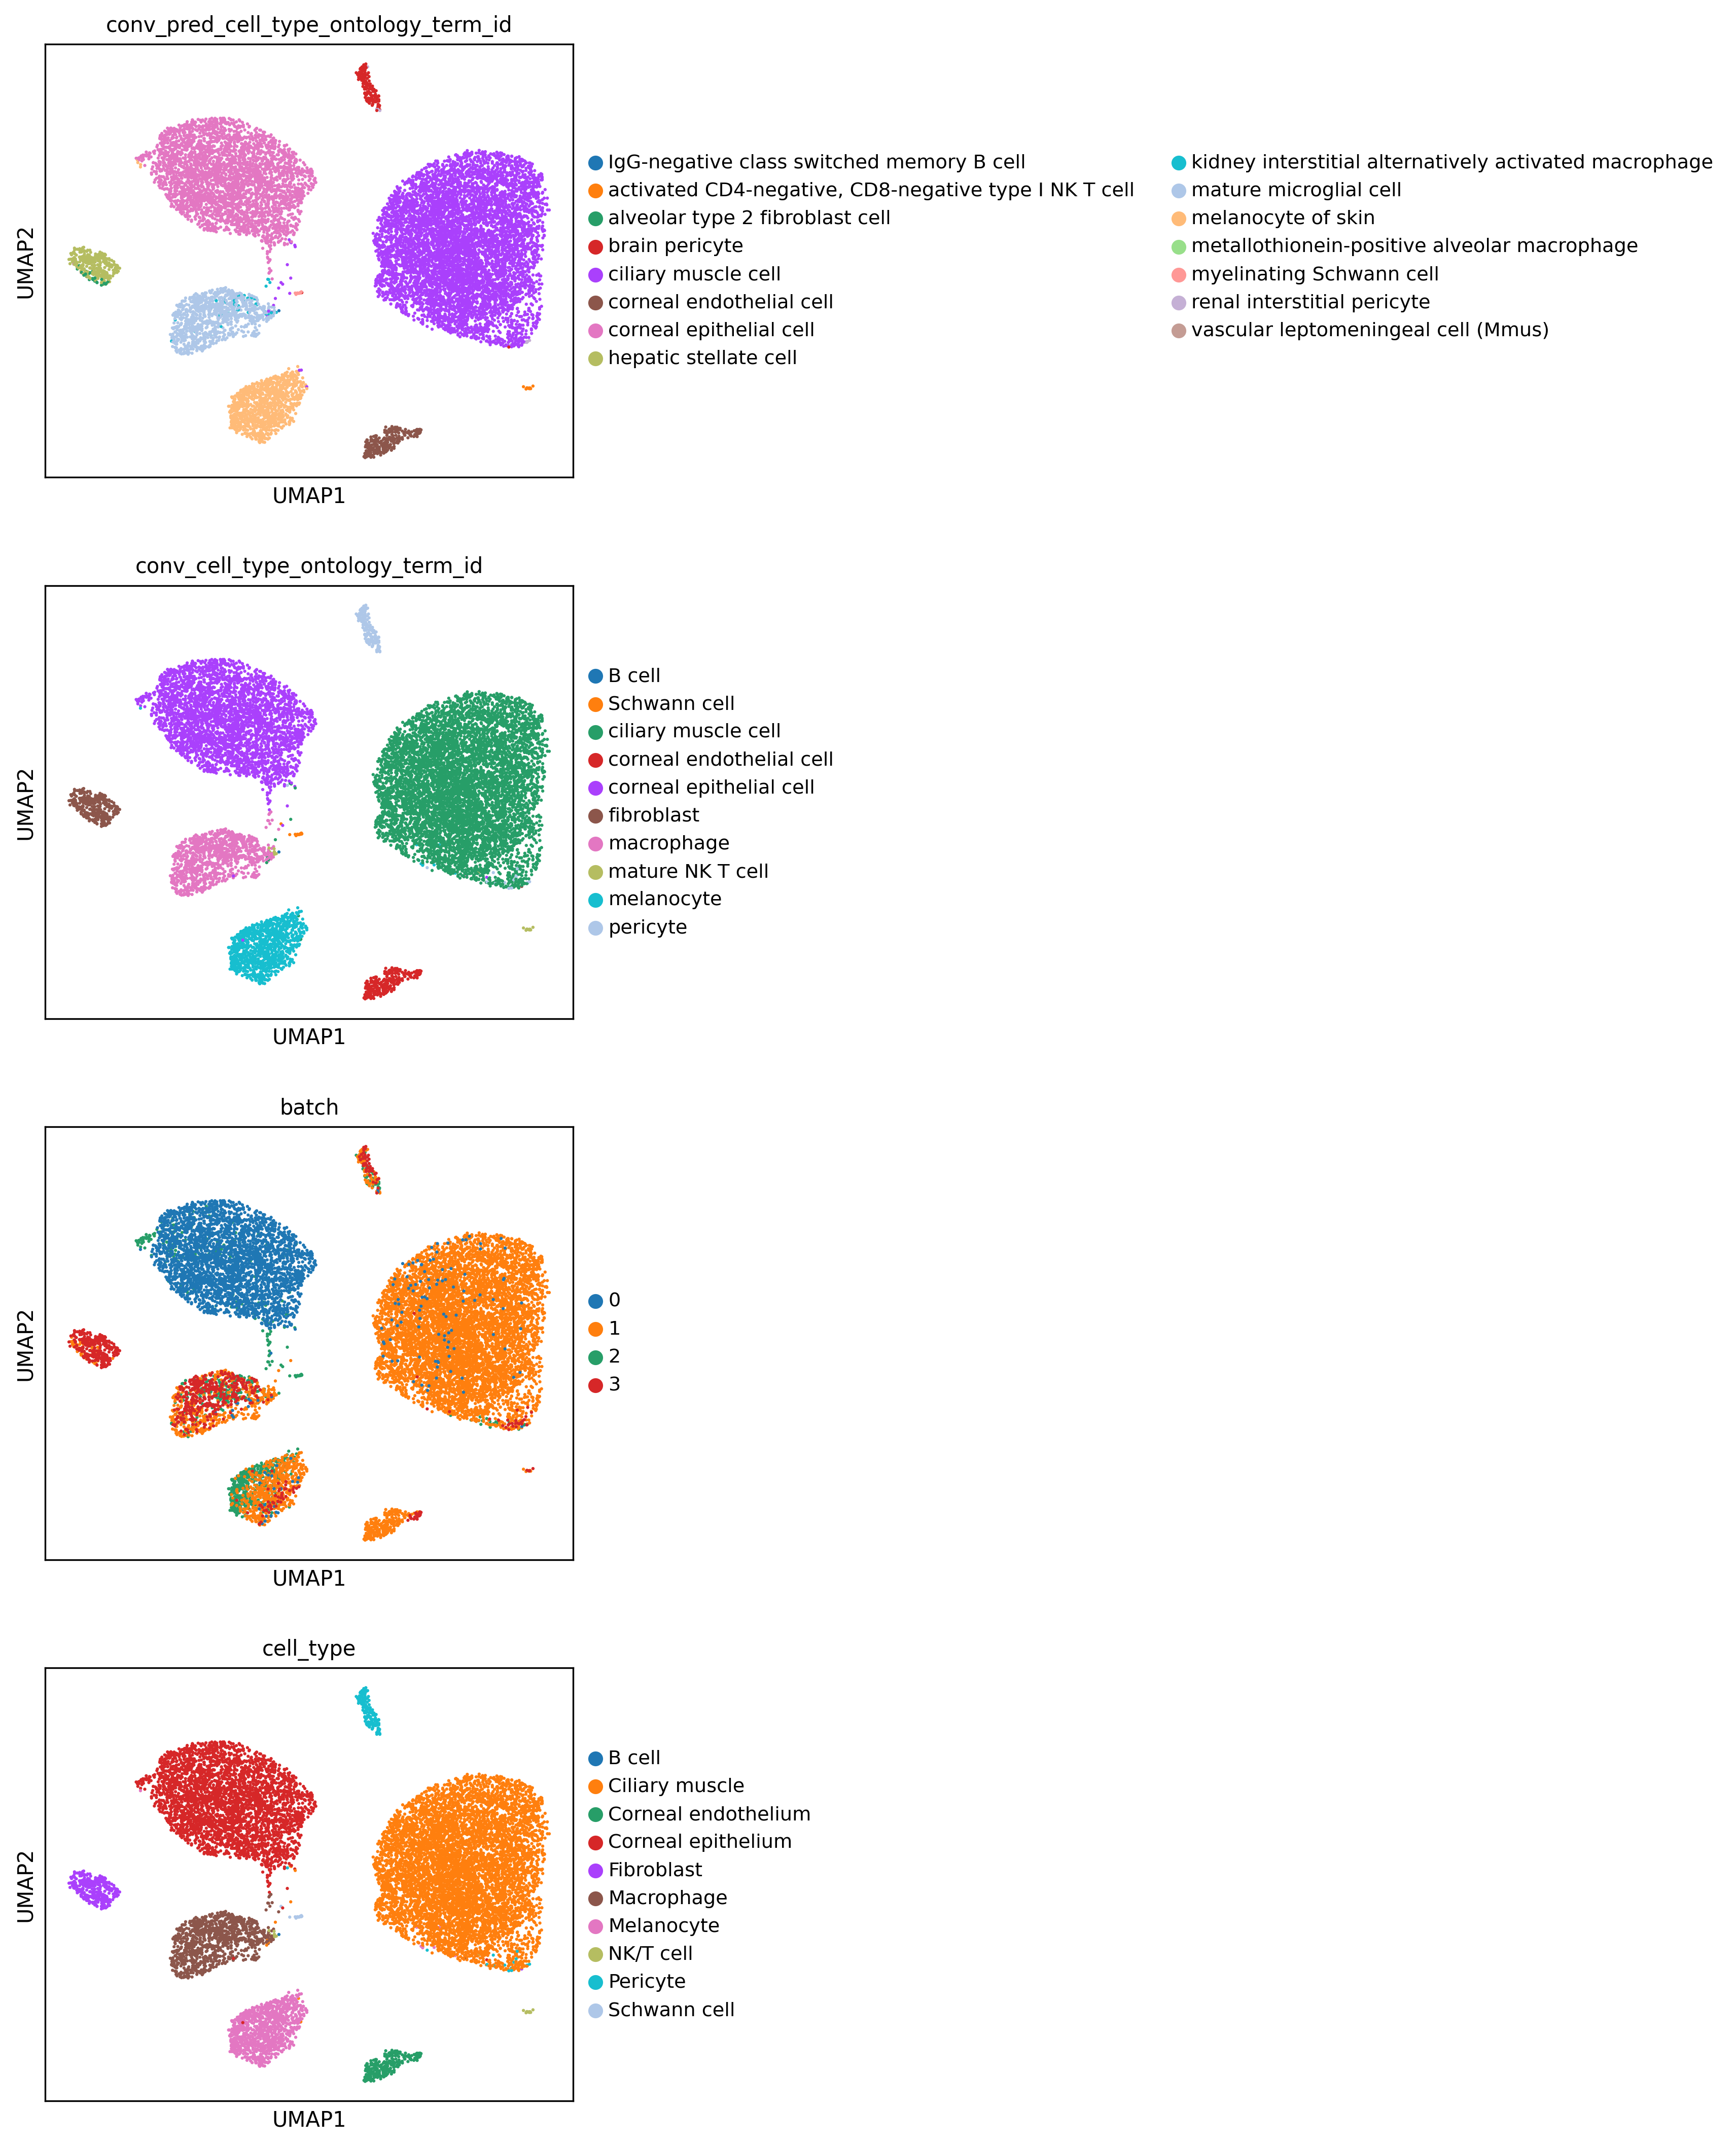

In [29]:
sc.pl.umap(
    n_adata,
    color=["conv_pred_cell_type_ontology_term_id", "conv_cell_type_ontology_term_id", "batch", "cell_type"],
    ncols=1,
)

#### Simplified labels (rare predicted types grouped as "other")

In [30]:
n_adata.obs["simple_cell_type"] = n_adata.obs[
    "conv_pred_cell_type_ontology_term_id"
].replace(
    {
        n: n if i > 100 else "other"
        for n, i in n_adata.obs["conv_pred_cell_type_ontology_term_id"]
        .value_counts()
        .items()
    }
)

/local/scratch/tmp/ipykernel_715116/3191472802.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  ].replace(


In [31]:
n_adata.obs["simple_cell_type"].value_counts()

simple_cell_type
ciliary muscle cell         6783
corneal epithelial cell     3409
melanocyte of skin          1081
mature microglial cell       989
hepatic stellate cell        307
corneal endothelial cell     280
brain pericyte               168
other                        119
Name: count, dtype: int64

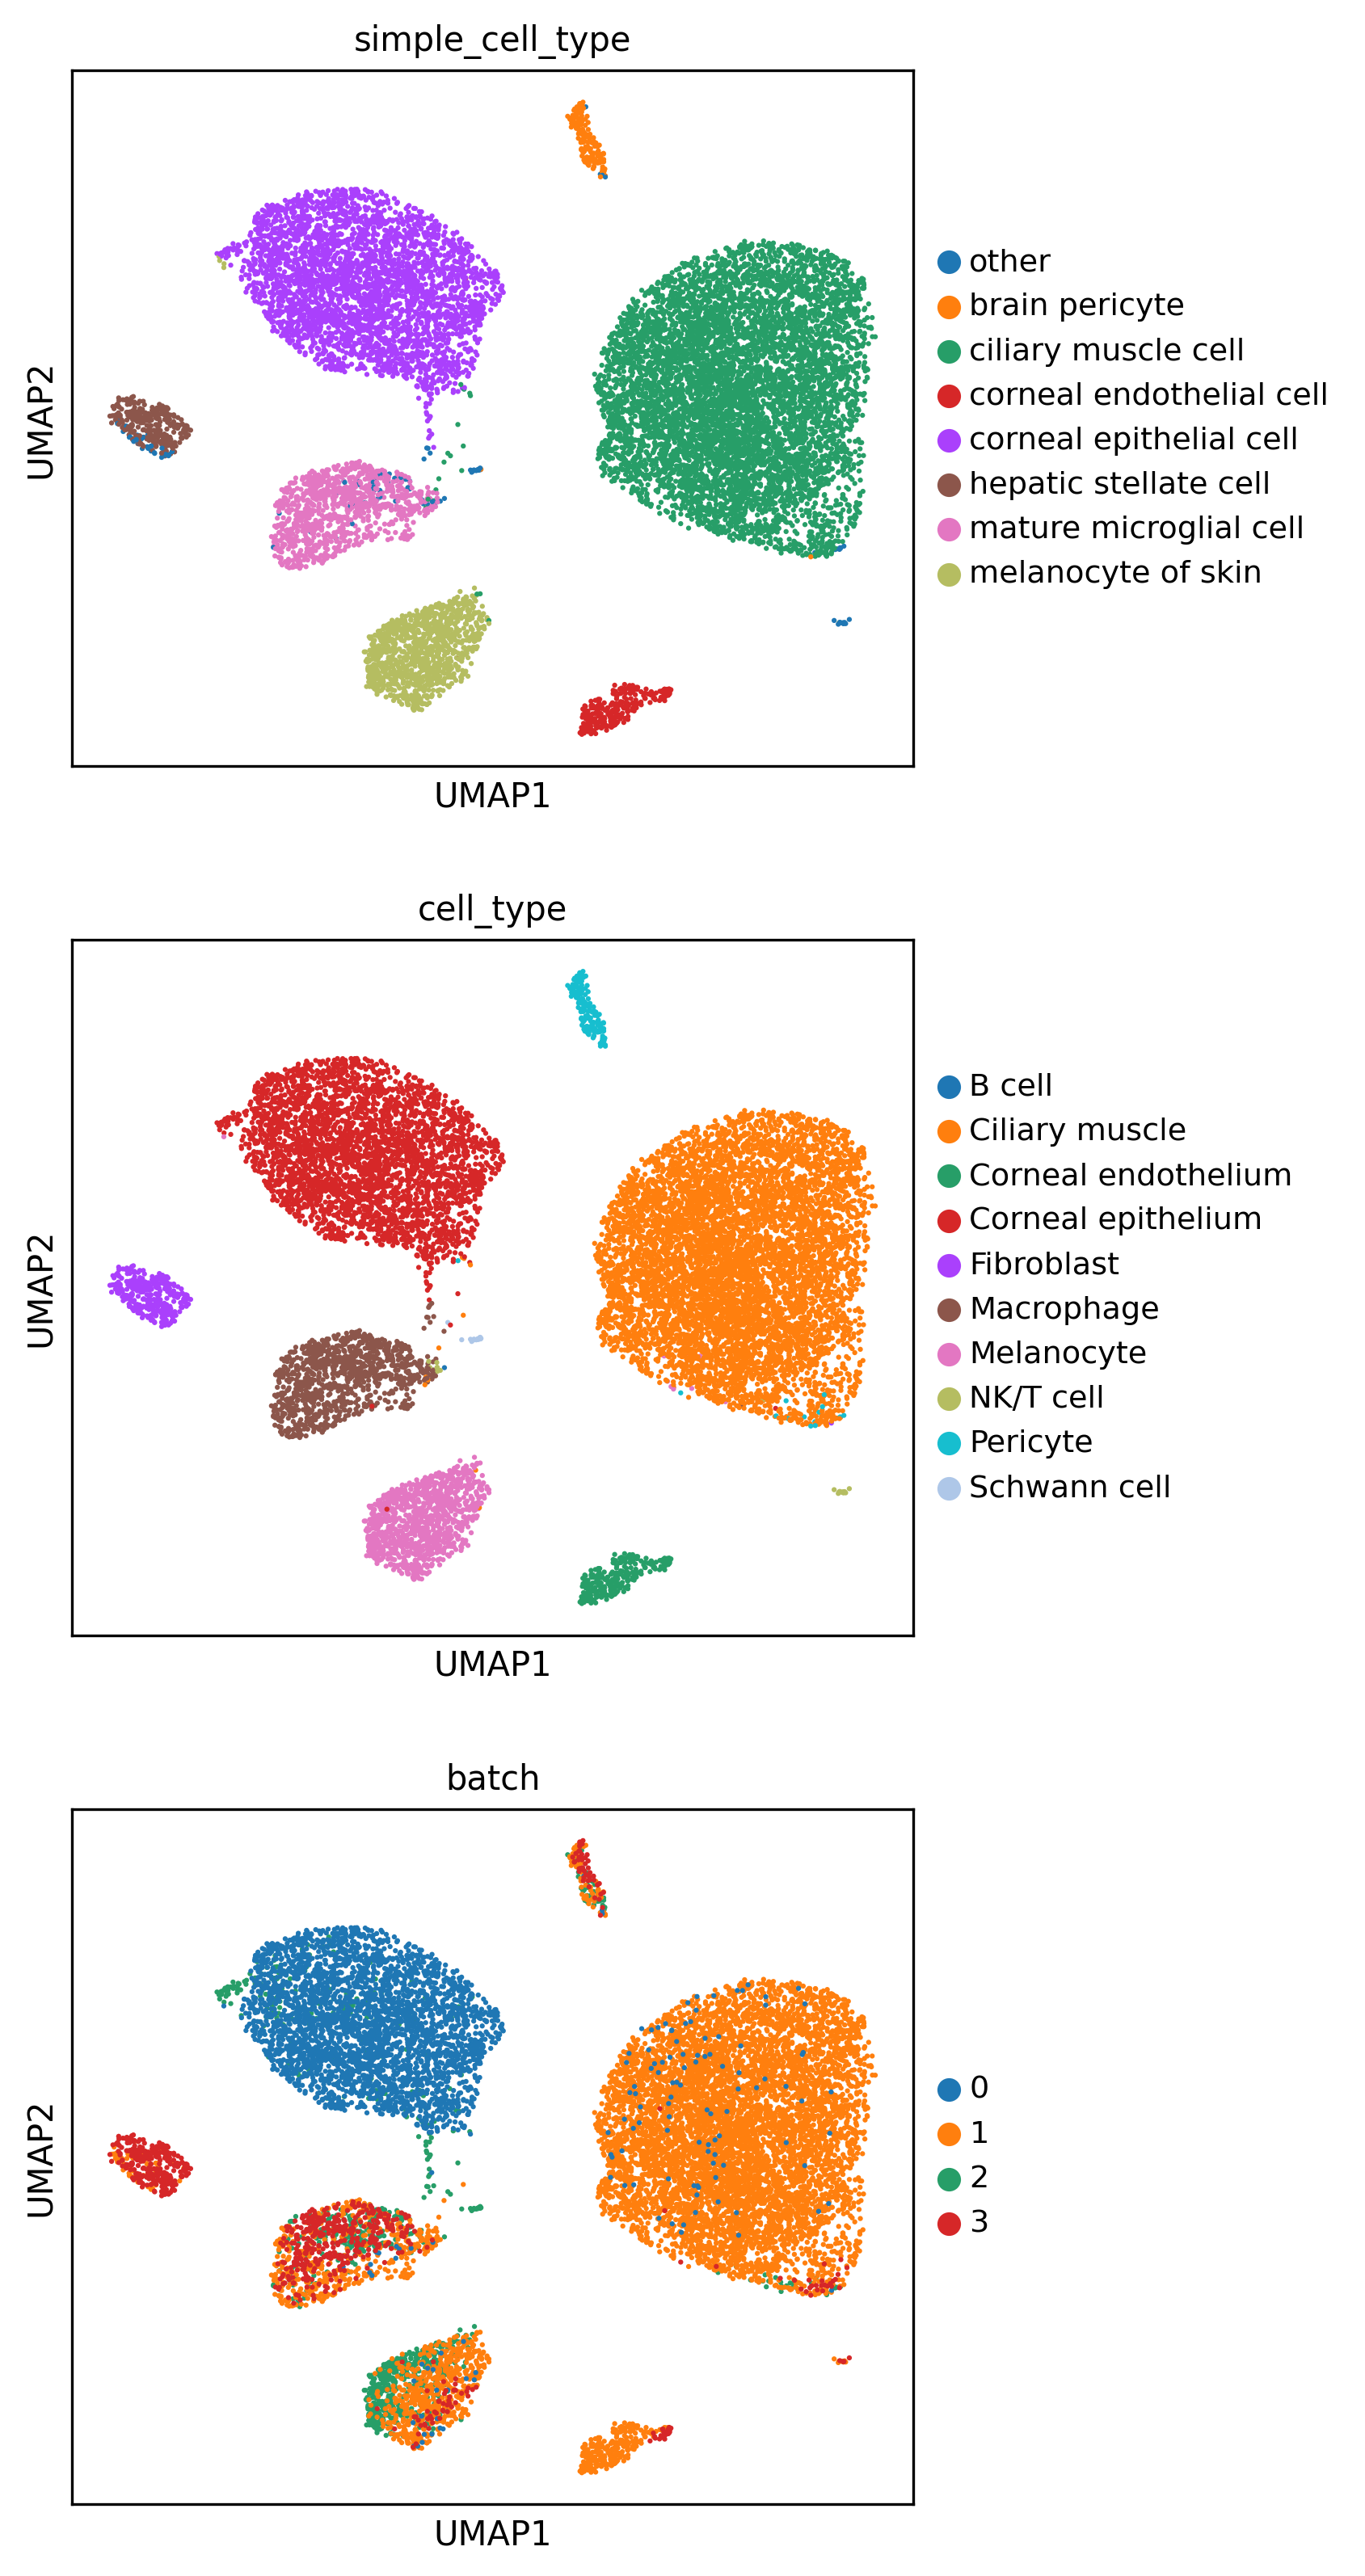

In [32]:
sc.pp.neighbors(n_adata, use_rep="scprint_emb_cell_type_ontology_term_id")
sc.tl.umap(n_adata)
sc.pl.umap(
    n_adata,
    color=["simple_cell_type", "cell_type", "batch"],
    ncols=1,
)

### Confusion matrices

Simplified vs. true labels, and raw predicted vs. true labels.

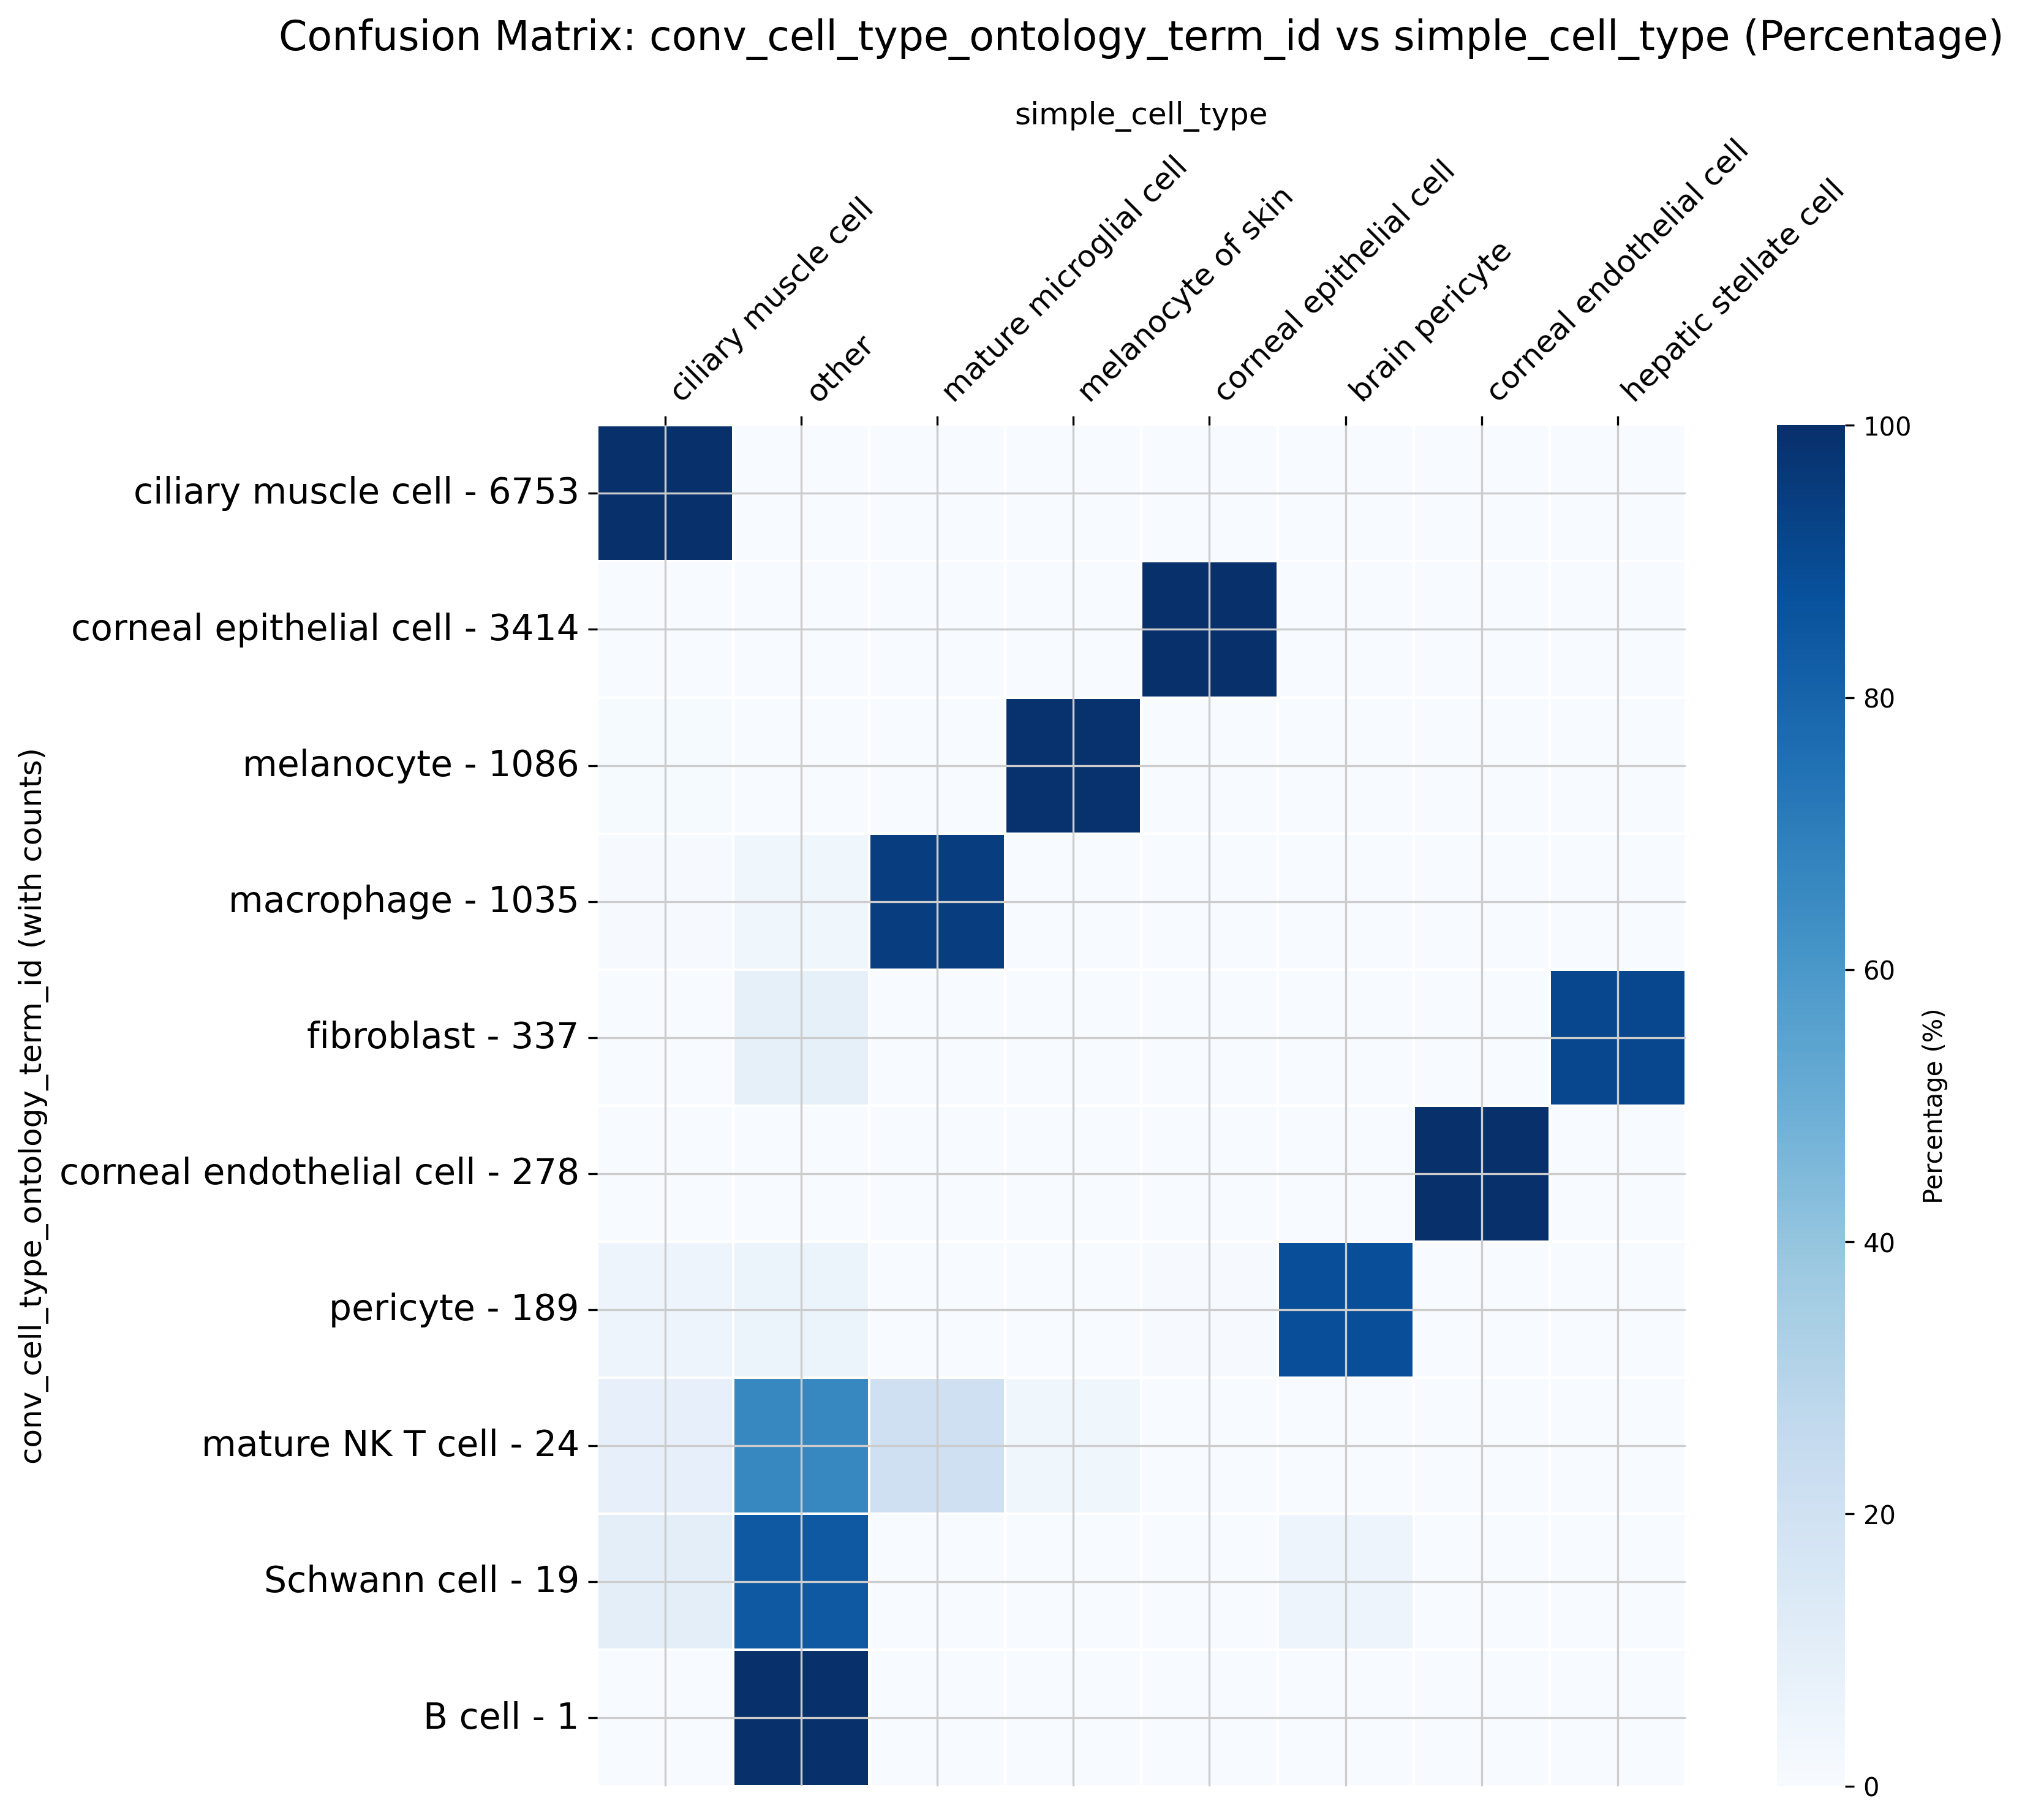

In [33]:
n_adata.obs["conv_pred_cell_type_ontology_term_id"] = translate(
    n_adata.obs["pred_cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)
n_adata.obs["conv_cell_type_ontology_term_id"] = translate(
    n_adata.obs["cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)
display_confusion_matrix(
    n_adata,
    "simple_cell_type",
    "conv_cell_type_ontology_term_id",
)

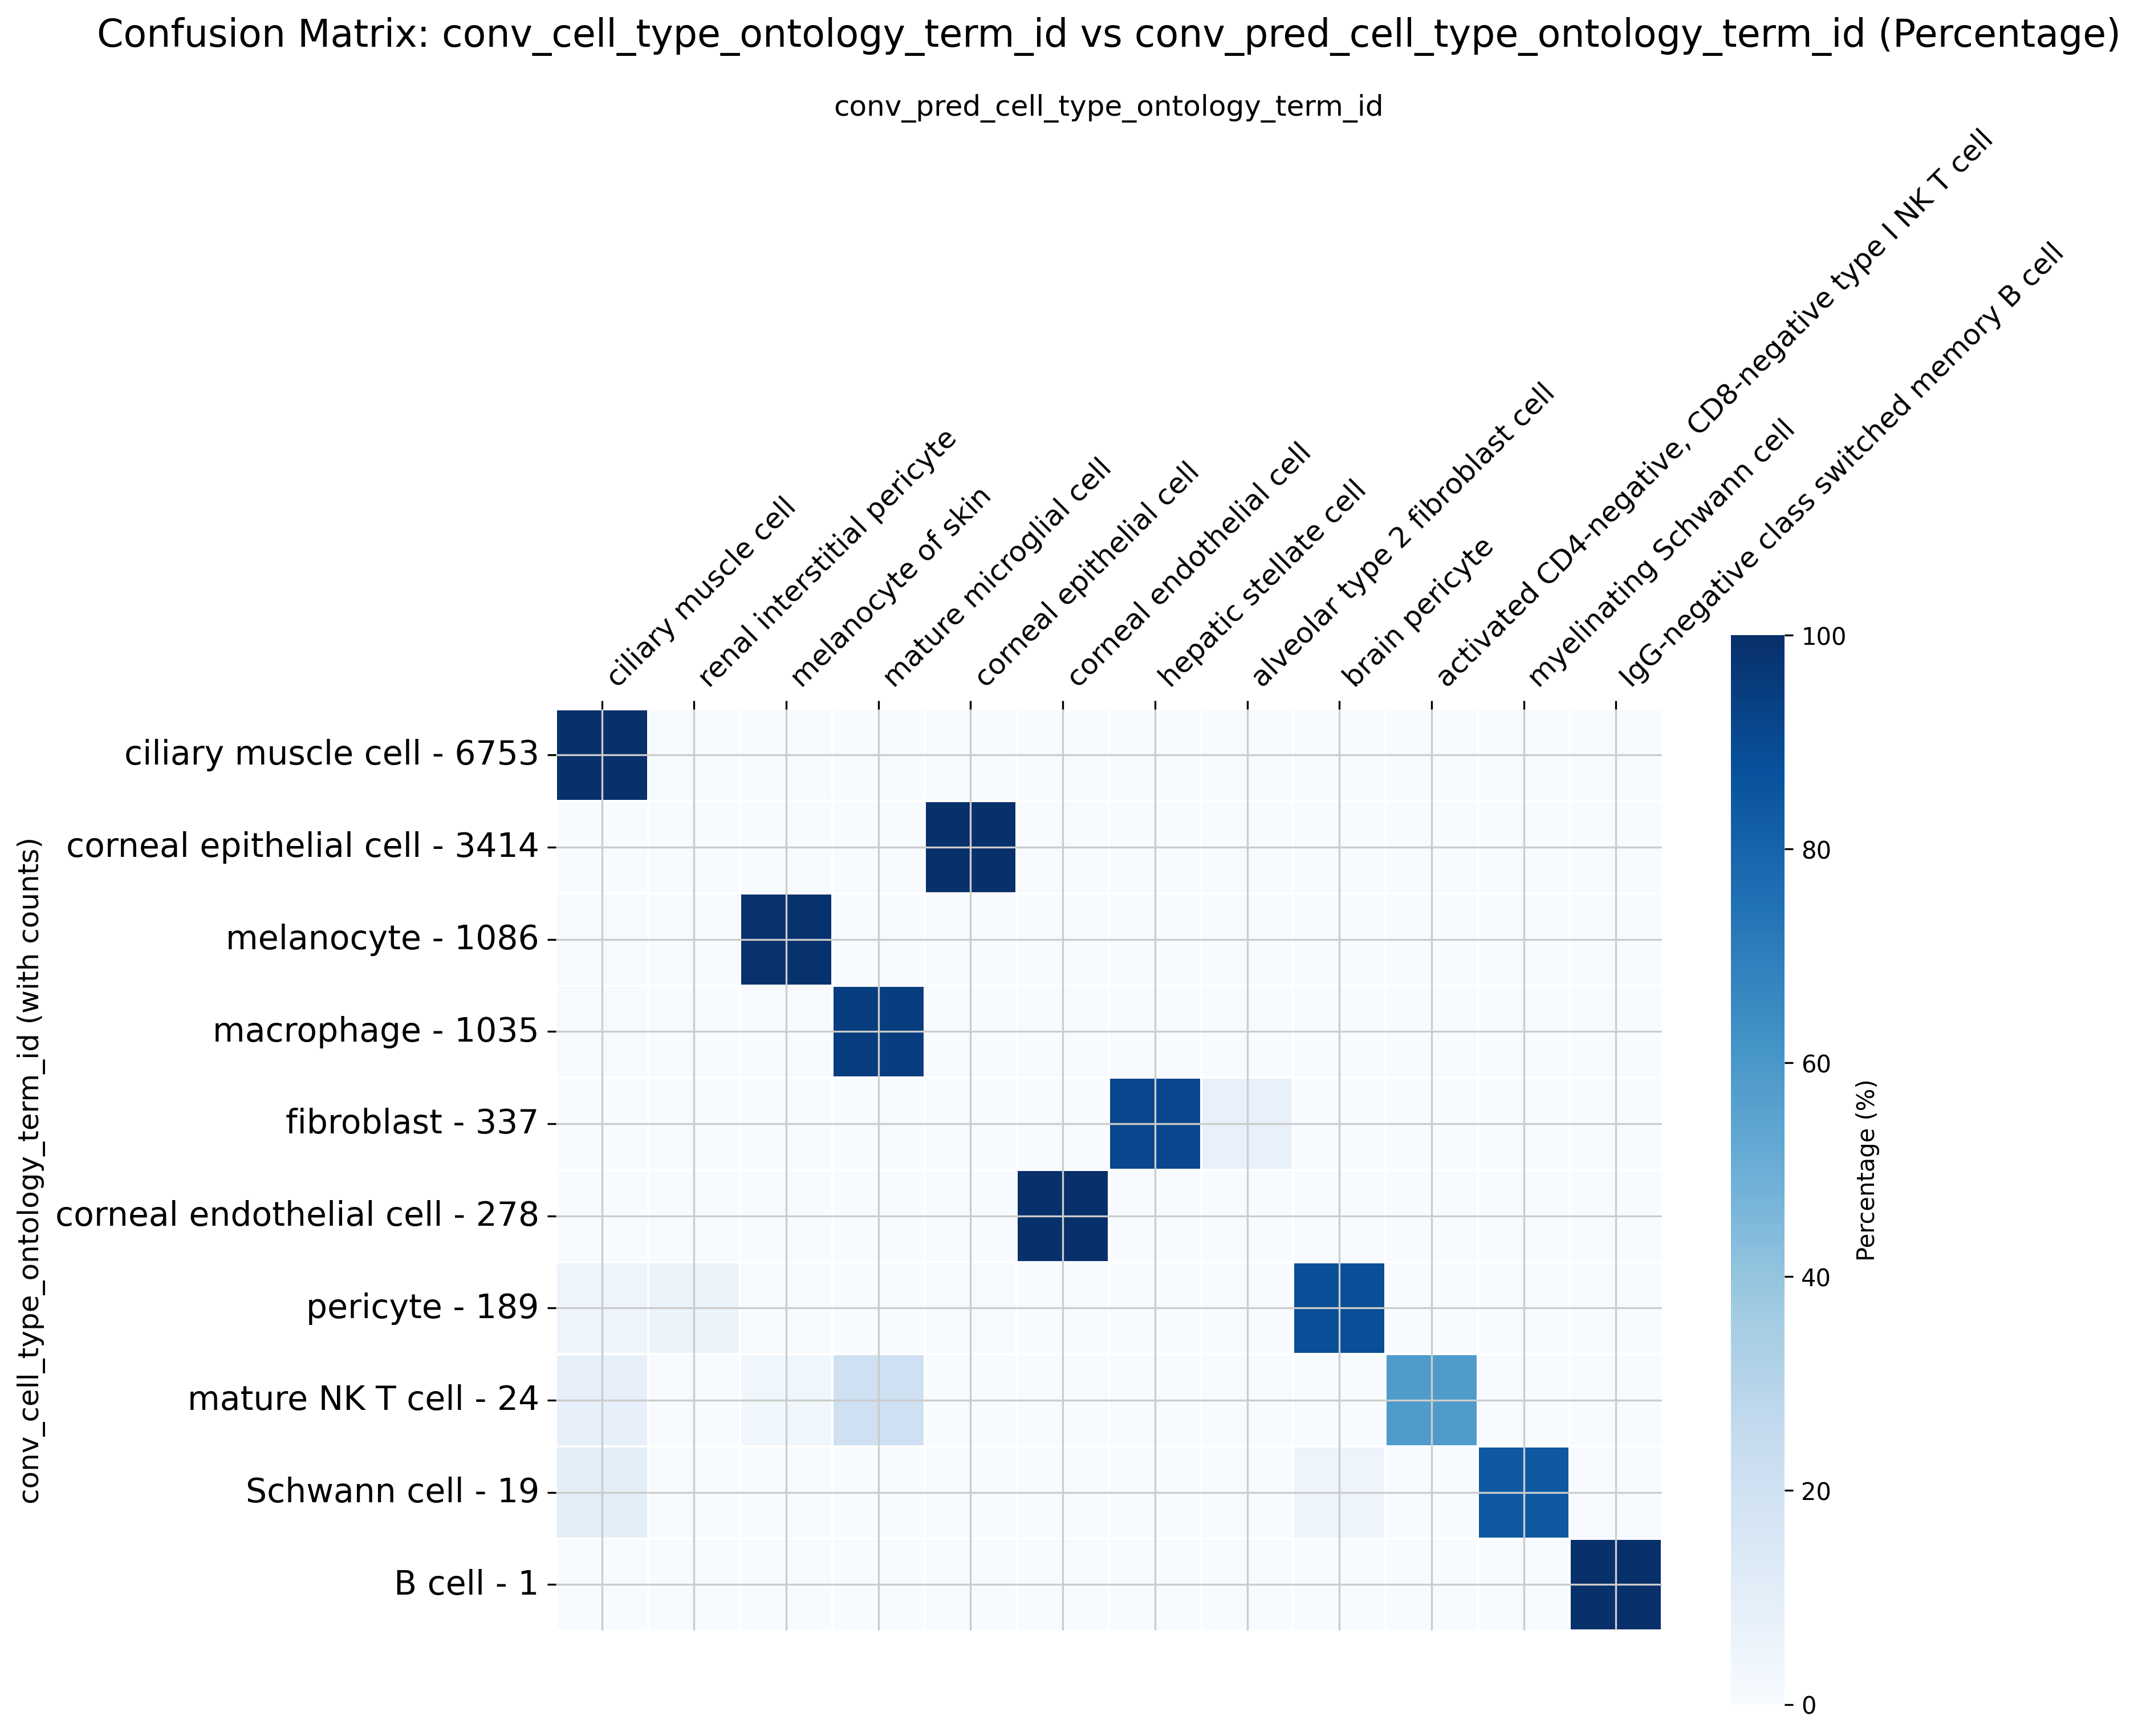

In [34]:
display_confusion_matrix(
    n_adata,
    "conv_pred_cell_type_ontology_term_id",
    "conv_cell_type_ontology_term_id",
)

### UMAPs
Same comparaison but on `scprint_emb`

... storing 'conv_pred_cell_type_ontology_term_id' as categorical
... storing 'conv_cell_type_ontology_term_id' as categorical


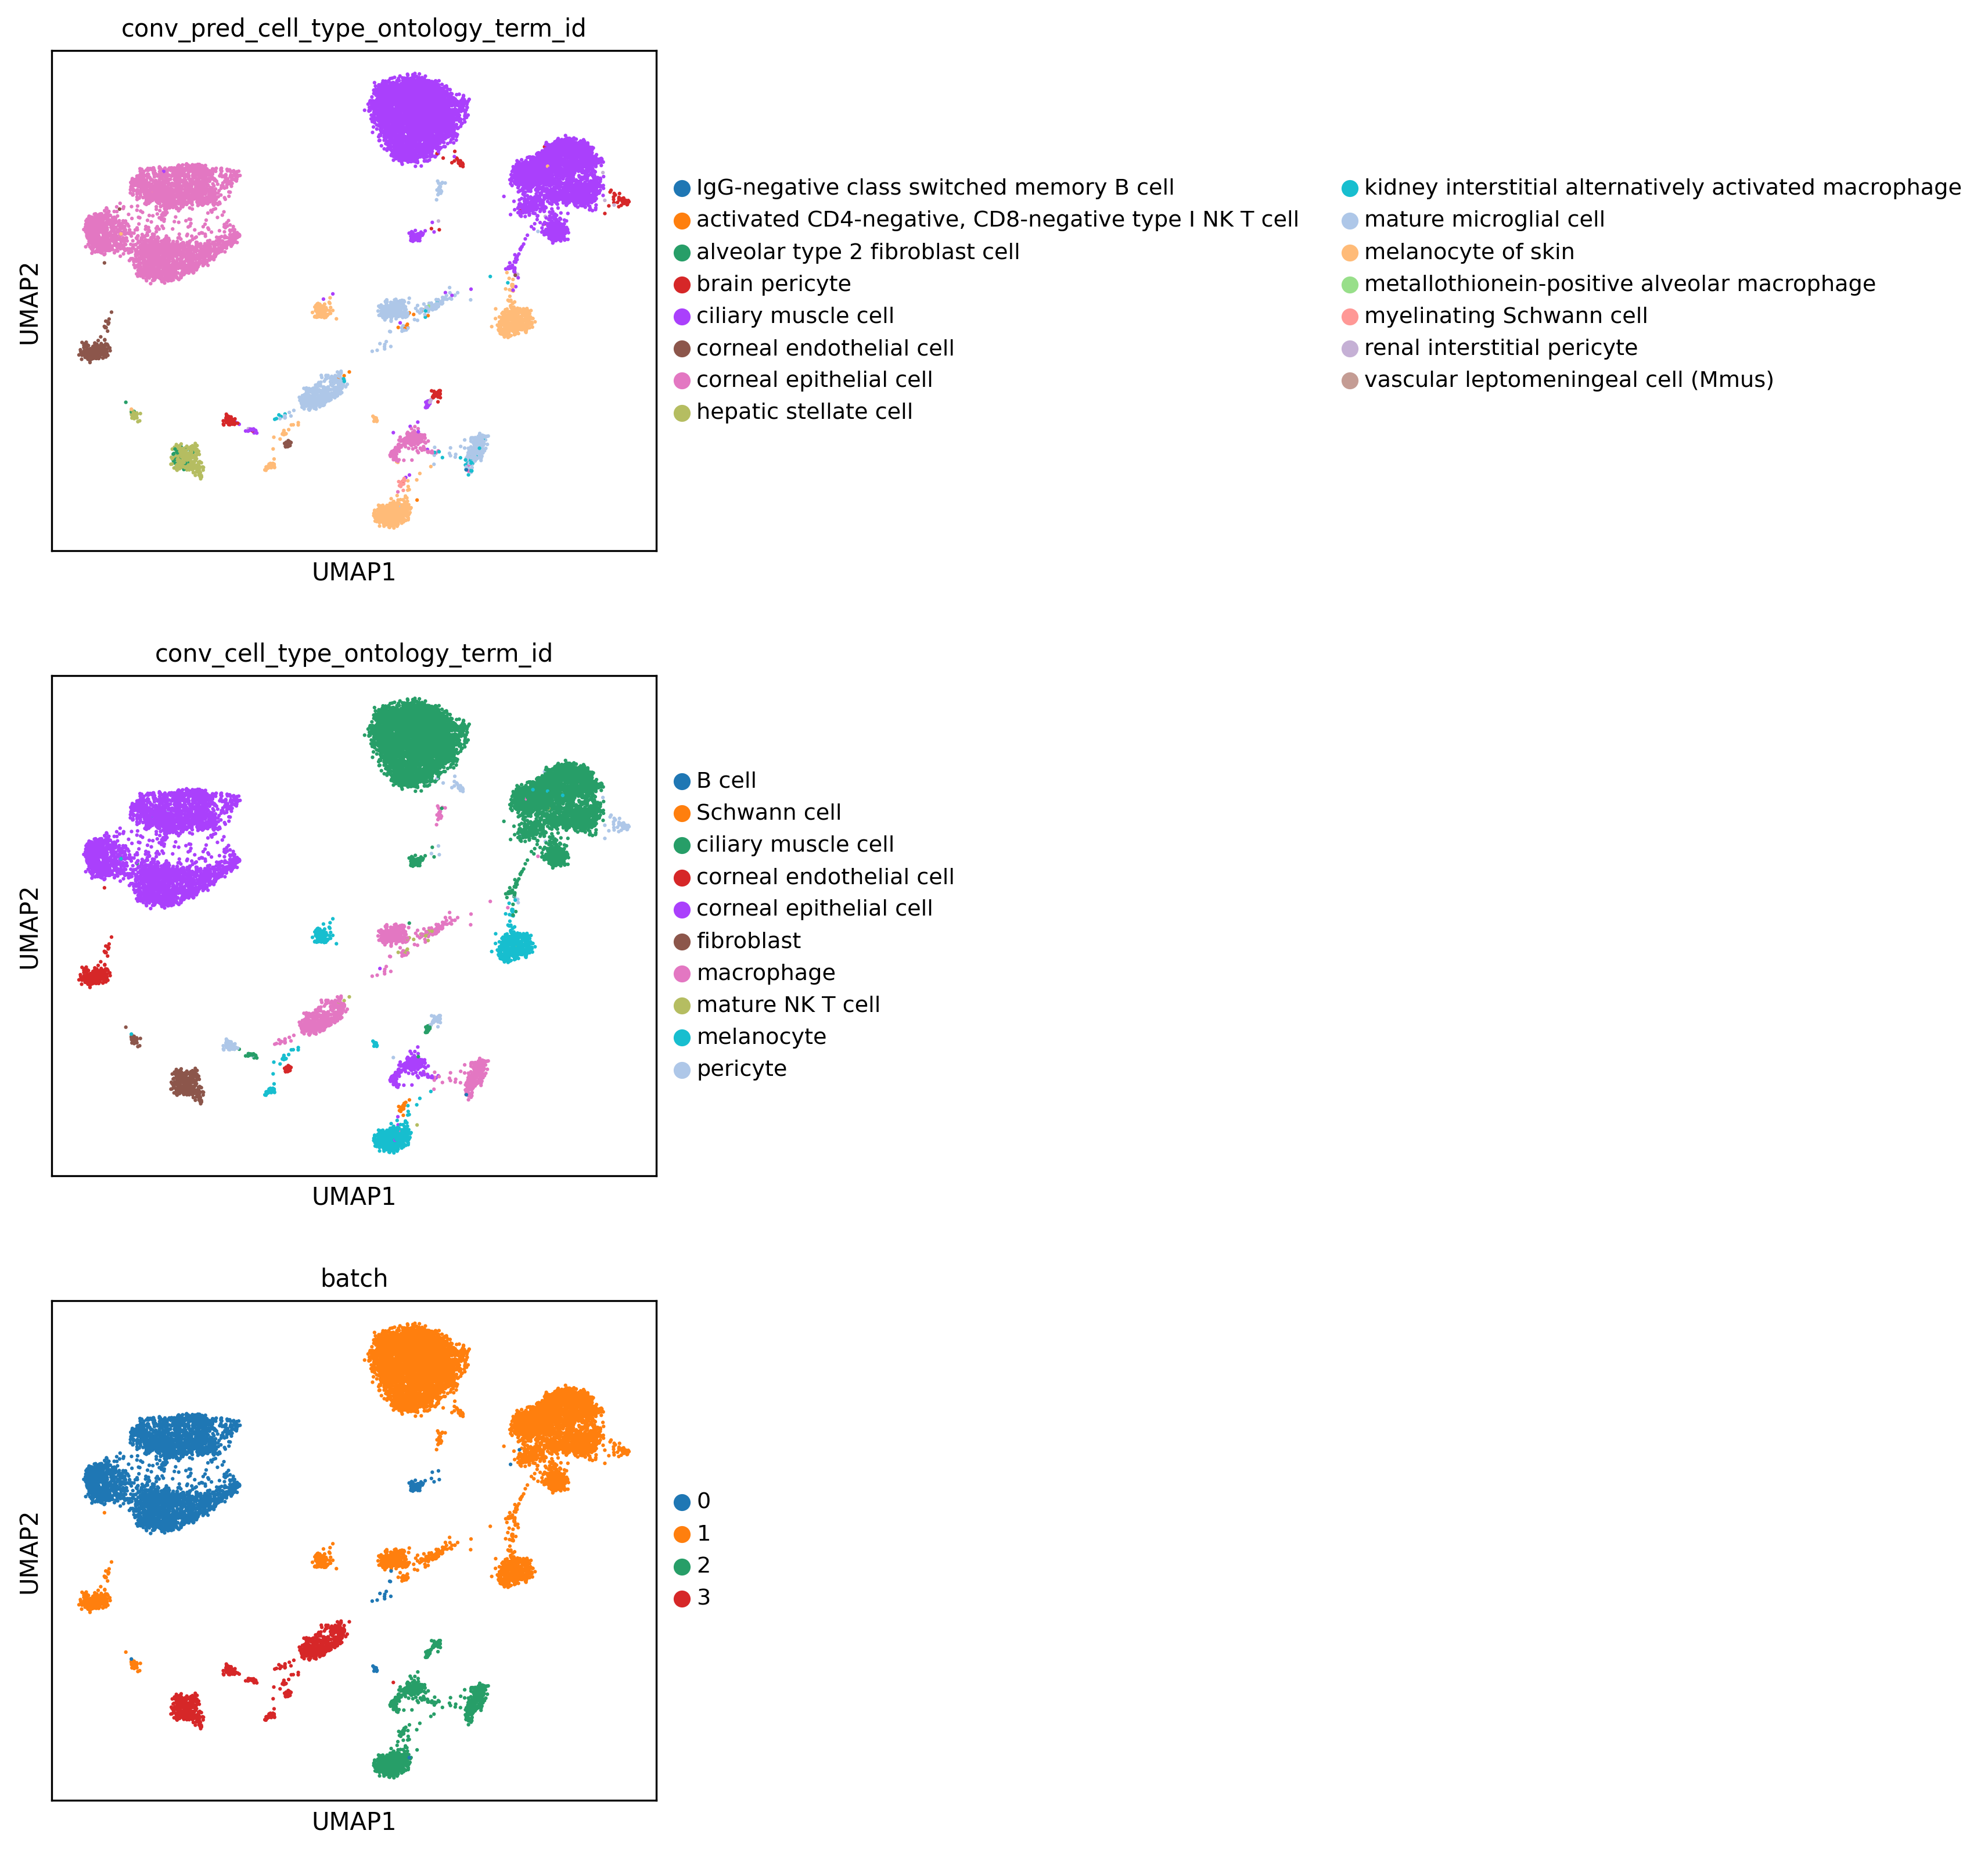

In [35]:
sc.pp.neighbors(n_adata, use_rep="scprint_emb")
sc.tl.umap(n_adata)
sc.pl.umap(
    n_adata,
    color=["conv_pred_cell_type_ontology_term_id", "conv_cell_type_ontology_term_id", "batch"],
    ncols=1,
)

### Prepare PCA and random baselines

In [36]:
sc.pp.normalize_total(n_adata, target_sum=1e4)
sc.pp.log1p(n_adata)
sc.pp.pca(n_adata)

In [37]:
n_adata.obsm["random"] = np.random.rand(*n_adata.obsm["X_pca"].shape)

In [38]:
sc.pp.neighbors(n_adata, use_rep="X_pca")

In [39]:
n_adata.obsm

AxisArrays with keys: X_pca, scprint_emb, scprint_emb_age_group, scprint_emb_assay_ontology_term_id, scprint_emb_cell_culture, scprint_emb_cell_type_ontology_term_id, scprint_emb_disease_ontology_term_id, scprint_emb_organism_ontology_term_id, scprint_emb_other, scprint_emb_self_reported_ethnicity_ontology_term_id, scprint_emb_sex_ontology_term_id, scprint_emb_tissue_ontology_term_id, X_umap, random

## scIB scores

In [40]:
bm = Benchmarker(
    n_adata,
    batch_key="batch",  # batch, tech, assay_ontology_term_id, donor_id
    label_key="cell_type_ontology_term_id",  # celltype
    embedding_obsm_keys=["scprint_emb_cell_type_ontology_term_id", "X_pca", "random", "scprint_emb"],
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    n_jobs=10,
)
bm.benchmark()
bm.get_results(min_max_scale=False)

/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
Computing neighbors:  50%|█████     | 2/4 [00:09<00:09,  4.96s/it]

Embeddings:   0%|          | 0/4 [00:00<?, ?it/s]Wed Aug 12 22:35:47 2026 INFO isolated labels: no more than 1 batches per label
INFO:2026-08-12 22:35:48,182:jax._src.xla_bridge:927: Unable to initialize backend 'cuda': 
Wed Aug 12 22:35:48 2026 INFO Unable to initialize backend 'cuda': 
INFO:2026-08-12 22:35:48,183:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
Wed Aug 12 22:35:48 2026 INFO Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-08-12 22:35:48,192:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
Wed Aug 12 22:35:48 2026 INFO Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
Wed Aug 12 22:35:48 2026 WARNING An NVIDIA GPU may 

INFO     CL:0000236 consists of a single batch or is too small. Skip.                                              


/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)


INFO     CL:0002573 consists of a single batch or is too small. Skip.                                              


...

INFO     CL:0000236 consists of a single batch or is too small. Skip.                                              


/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)


INFO     CL:0002573 consists of a single batch or is too small. Skip.                                              


/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_graph_connectivity.py:30: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
Embeddings: 100%|██████████| 4/4 [03:07<00:00, 46.83s/it]


,Isolated labels,KMeans NMI,KMeans ARI,Silhouette label,cLISI,Silhouette batch,iLISI,KBET,Graph connectivity,PCR comparison,Batch correction,Bio conservation,Total
Embedding,,,,,,,,,,,,,
scprint_emb_cell_type_ontology_term_id,0.667344,0.856121,0.695953,0.83084,1.0,0.780617,0.00217,0.538996,0.972101,0.281382,0.515053,0.810052,0.692052
X_pca,0.564172,0.604539,0.356487,0.600305,1.0,0.701205,0.0,0.124856,0.712747,0.0,0.307762,0.625101,0.498165
random,0.493347,0.001636,0.00001,0.484274,0.824225,0.98574,0.376869,0.599605,0.288359,0.999481,0.650011,0.360698,0.476423
scprint_emb,0.548283,0.673363,0.493763,0.590209,1.0,0.78969,0.0,0.123157,0.680923,0.313162,0.381386,0.661124,0.549229
Metric Type,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Batch correction,Batch correction,Batch correction,Batch correction,Batch correction,Aggregate score,Aggregate score,Aggregate score


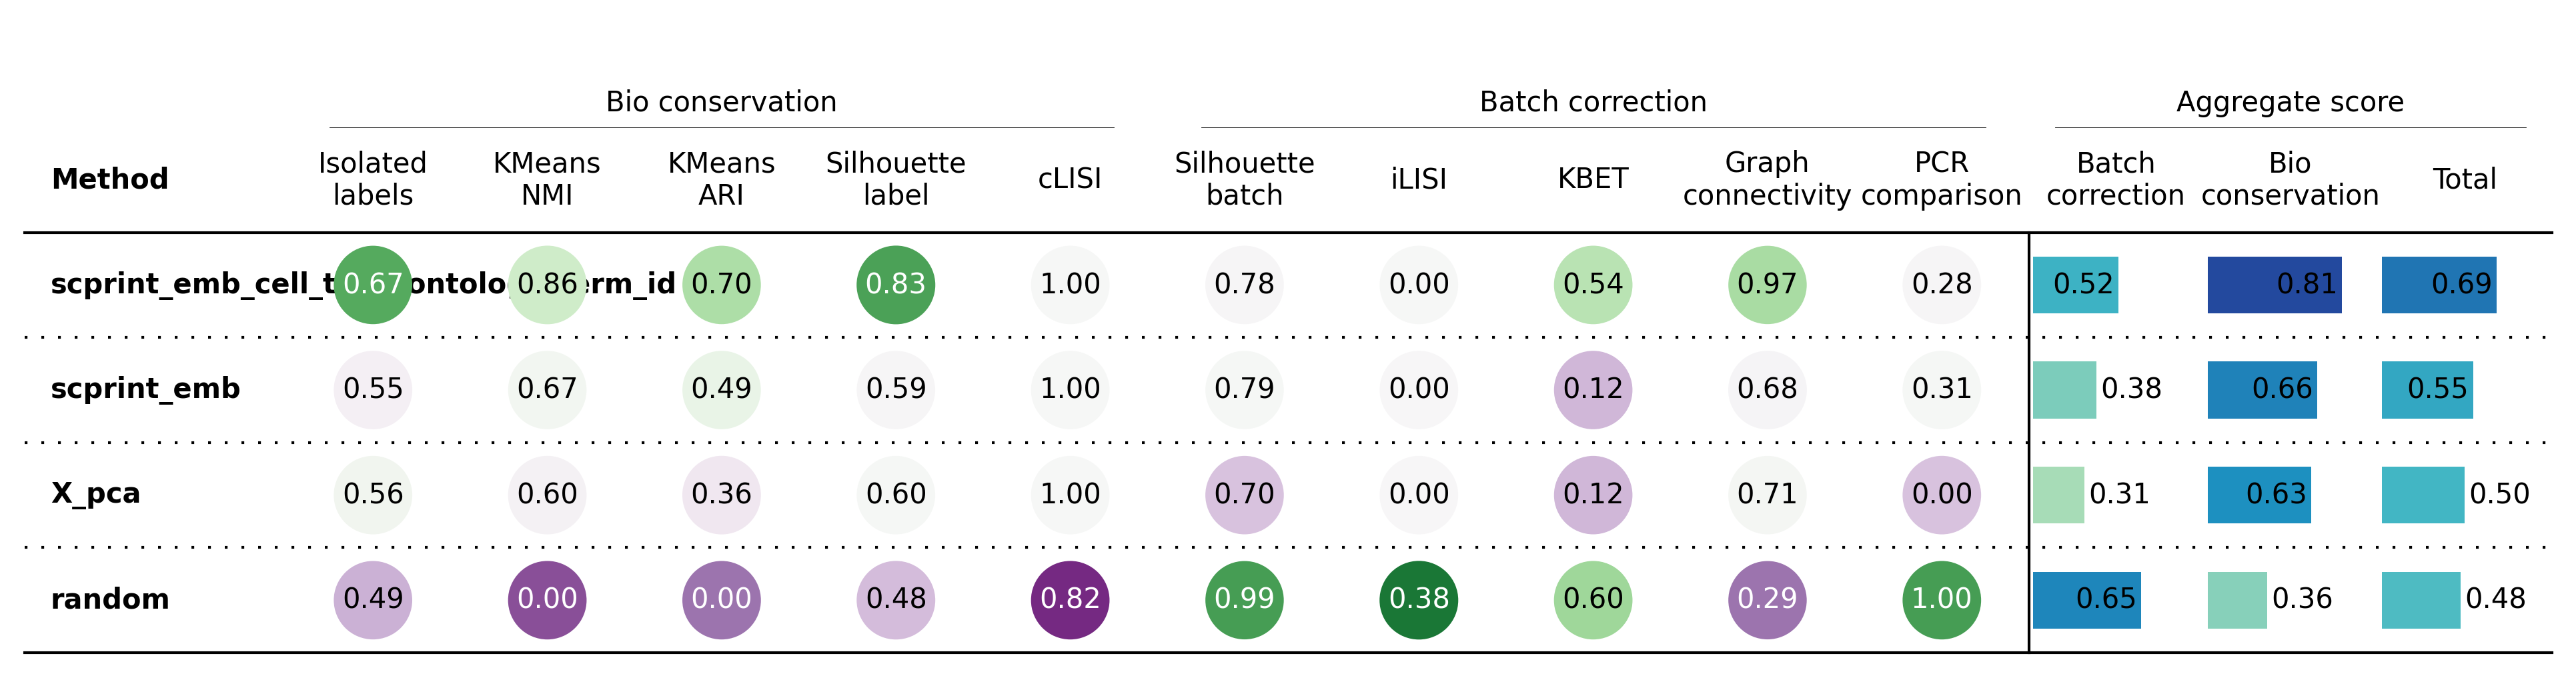

In [41]:
# after fine tuning cell type embedding
bm.plot_results_table(min_max_scale=False)